In [2]:
import os
from scipy.io import loadmat

ib_folder = r"C:\MachineHealthProject\data\IB"

data_path = os.path.join(ib_folder, "data.mat")
targets_path = os.path.join(ib_folder, "targets.mat")

# Load the MAT files
data_mat = loadmat(data_path)
targets_mat = loadmat(targets_path)

print("=== data.mat ===")
print(data_mat.keys())

print("\n=== targets.mat ===")
print(targets_mat.keys())

=== data.mat ===
dict_keys(['__header__', '__version__', '__globals__', 'Data'])

=== targets.mat ===
dict_keys(['__header__', '__version__', '__globals__', 'Targets'])


In [3]:
import numpy as np

# Extract data and targets
ib_data = data_mat["Data"]
ib_targets = targets_mat["Targets"]

print("=== IB DATASET INFORMATION ===")

print("Data type:", type(ib_data))
print("Data shape:", ib_data.shape)
print("Data dtype:", ib_data.dtype)

print("\nTargets type:", type(ib_targets))
print("Targets shape:", ib_targets.shape)
print("Targets dtype:", ib_targets.dtype)

print("\nFirst few target values:")
print(ib_targets.flatten()[:20])

=== IB DATASET INFORMATION ===
Data type: <class 'numpy.ndarray'>
Data shape: (178, 3571)
Data dtype: float64

Targets type: <class 'numpy.ndarray'>
Targets shape: (178, 1)
Targets dtype: uint8

First few target values:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


=== IB CLASS DISTRIBUTION ===
Class 1: 20 samples
Class 2: 20 samples
Class 3: 19 samples
Class 4: 20 samples
Class 5: 20 samples
Class 6: 19 samples
Class 7: 20 samples
Class 8: 20 samples
Class 9: 20 samples

Total samples: 178
Number of classes: 9


,Class,Count
0,1,20
1,2,20
2,3,19
3,4,20
4,5,20
5,6,19
6,7,20
7,8,20
8,9,20


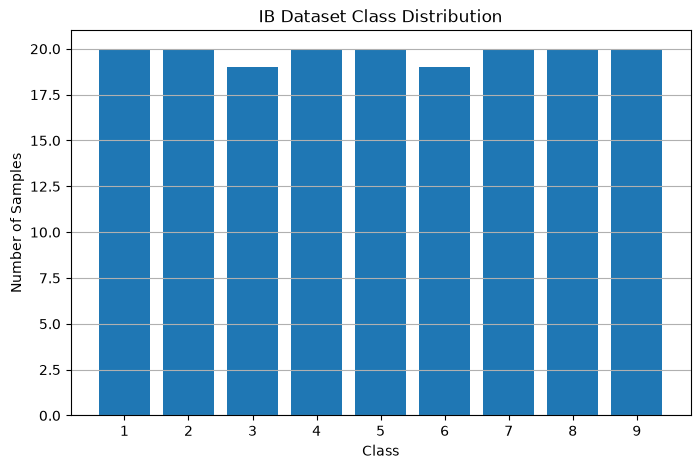

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Flatten targets
ib_labels = ib_targets.flatten()

# Find unique classes and their counts
unique_labels, label_counts = np.unique(
    ib_labels,
    return_counts=True
)

print("=== IB CLASS DISTRIBUTION ===")

for label, count in zip(unique_labels, label_counts):
    print(f"Class {label}: {count} samples")

print("\nTotal samples:", len(ib_labels))
print("Number of classes:", len(unique_labels))

# Create table
ib_class_df = pd.DataFrame({
    "Class": unique_labels,
    "Count": label_counts
})

display(ib_class_df)

# Plot
plt.figure(figsize=(8, 5))

plt.bar(
    [str(x) for x in unique_labels],
    label_counts
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("IB Dataset Class Distribution")
plt.grid(axis="y")

plt.show()

In [5]:
import numpy as np
import pandas as pd

print("=== IB RAW DATA EDA ===\n")

# Basic information
print("Shape:", ib_data.shape)
print("Data type:", ib_data.dtype)

# Missing values
print("\nMissing values:")
print("NaN:", np.isnan(ib_data).sum())
print("Infinite:", np.isinf(ib_data).sum())

# Basic statistics
print("\nOverall statistics:")
print("Minimum:", np.min(ib_data))
print("Maximum:", np.max(ib_data))
print("Mean:", np.mean(ib_data))
print("Median:", np.median(ib_data))
print("Standard deviation:", np.std(ib_data))
print("Variance:", np.var(ib_data))

# Duplicate rows
print("\nDuplicate samples:")
ib_duplicate_rows = pd.DataFrame(ib_data).duplicated().sum()
print(ib_duplicate_rows)

# First sample
print("\nFirst sample - first 20 values:")
print(ib_data[0, :20])

# Label information
print("\nNumber of unique labels:", len(np.unique(ib_targets)))
print("Labels:", np.unique(ib_targets).flatten())

=== IB RAW DATA EDA ===

Shape: (178, 3571)
Data type: float64

Missing values:
NaN: 0
Infinite: 0

Overall statistics:
Minimum: -3.3797
Maximum: 1.3992
Mean: -0.003071306309566138
Median: 0.0147
Standard deviation: 0.1570016233024079
Variance: 0.0246495097195912

Duplicate samples:
0

First sample - first 20 values:
[ 0.0069  0.0069  0.0176  0.0186  0.002   0.005  -0.0164 -0.0125 -0.0145
 -0.0193 -0.0164 -0.0155 -0.0184 -0.0193 -0.0262 -0.0203 -0.0077  0.0001
  0.0127  0.005 ]

Number of unique labels: 9
Labels: [1 2 3 4 5 6 7 8 9]


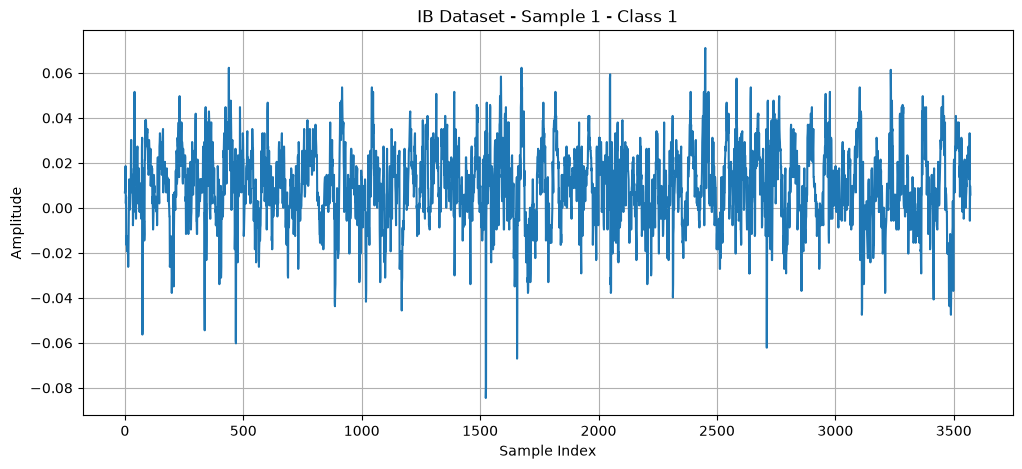

Sample number: 1
Class: 1
Number of values: 3571
Minimum: -0.0845
Maximum: 0.0711


In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Select first sample
sample = ib_data[0]

# Create sample index
x = np.arange(len(sample))

plt.figure(figsize=(12, 5))

plt.plot(x, sample)

plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.title(f"IB Dataset - Sample 1 - Class {ib_labels[0]}")
plt.grid(True)

plt.show()

print("Sample number:", 1)
print("Class:", ib_labels[0])
print("Number of values:", len(sample))
print("Minimum:", np.min(sample))
print("Maximum:", np.max(sample))

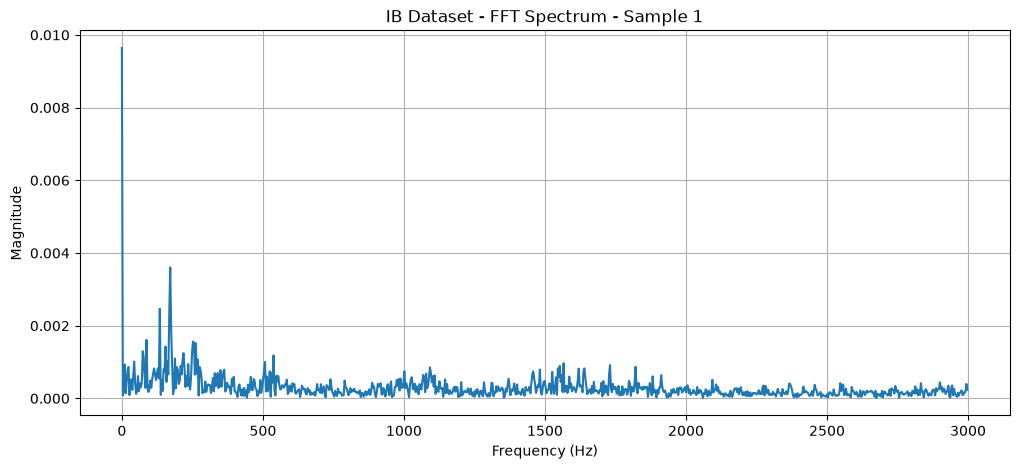

Top 10 frequency components:
171.38 Hz -> Magnitude: 0.003601
134.42 Hz -> Magnitude: 0.002464
168.02 Hz -> Magnitude: 0.002342
174.74 Hz -> Magnitude: 0.001883
87.37 Hz -> Magnitude: 0.001611
252.03 Hz -> Magnitude: 0.001564
255.39 Hz -> Magnitude: 0.001538
262.11 Hz -> Magnitude: 0.001519
154.58 Hz -> Magnitude: 0.001427
73.93 Hz -> Magnitude: 0.001298


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Select first IB sample
signal = ib_data[0]

# Sampling frequency
# This dataset is provided as sampled signal data.
# We use 12000 Hz here for frequency-domain visualization.
sampling_rate = 12000

# FFT
N = len(signal)

fft_values = np.fft.rfft(signal)
frequencies = np.fft.rfftfreq(N, d=1 / sampling_rate)

magnitude = np.abs(fft_values) / N

# Limit frequency for clearer visualization
max_frequency = 3000
mask = frequencies <= max_frequency

plt.figure(figsize=(12, 5))

plt.plot(
    frequencies[mask],
    magnitude[mask]
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("IB Dataset - FFT Spectrum - Sample 1")
plt.grid(True)

plt.show()

# Find dominant frequencies
peak_indices = np.argsort(magnitude[1:])[-10:] + 1
peak_indices = peak_indices[
    np.argsort(magnitude[peak_indices])[::-1]
]

print("Top 10 frequency components:")

for i in peak_indices:
    print(
        f"{frequencies[i]:.2f} Hz -> "
        f"Magnitude: {magnitude[i]:.6f}"
    )

In [8]:
import numpy as np
import pandas as pd

ib_features = []

for i in range(len(ib_data)):

    signal = ib_data[i]

    rms = np.sqrt(np.mean(signal ** 2))

    features = {
        "Sample": i + 1,
        "Label": int(ib_labels[i]),

        "Samples": len(signal),

        "Mean": np.mean(signal),
        "Median": np.median(signal),
        "Std": np.std(signal),

        "Min": np.min(signal),
        "Max": np.max(signal),

        "RMS": rms,

        "Peak_to_Peak": np.max(signal) - np.min(signal),

        "Variance": np.var(signal),

        "Crest_Factor": np.max(np.abs(signal)) / rms
    }

    ib_features.append(features)

ib_df = pd.DataFrame(ib_features)

print("=== IB FEATURE DATASET ===")
print("Number of samples:", ib_df.shape[0])
print("Number of columns:", ib_df.shape[1])

display(ib_df.head())

=== IB FEATURE DATASET ===
Number of samples: 178
Number of columns: 12


,Sample,Label,Samples,Mean,Median,Std,Min,Max,RMS,Peak_to_Peak,Variance,Crest_Factor
0,1,1,3571,0.009641,0.0098,0.017640,-0.0845,0.0711,0.020103,0.1556,0.000311,4.203444
1,2,1,3571,0.010269,0.0108,0.059201,-3.3340,0.1002,0.060085,3.4342,0.003505,55.488031
2,3,1,3571,0.008430,0.0088,0.018029,-0.0874,0.0750,0.019902,0.1624,0.000325,4.391489
3,4,1,3571,0.044781,0.0458,0.018601,-0.0495,0.1226,0.048490,0.1721,0.000346,2.528338
4,5,1,3571,0.012959,0.0137,0.018746,-0.0709,0.0720,0.022789,0.1429,0.000351,3.159440


In [9]:
print("=== IB FEATURE DATA QUALITY ===")

print("\nMissing values:")
print(ib_df.isnull().sum())

print("\nDuplicate rows:")
print(ib_df.duplicated().sum())

print("\nInfinite values:")
print(np.isinf(ib_df.select_dtypes(include=np.number)).sum().sum())

print("\nFeature statistics:")
display(ib_df.describe().T)

=== IB FEATURE DATA QUALITY ===

Missing values:
Sample          0
Label           0
Samples         0
Mean            0
Median          0
Std             0
Min             0
Max             0
RMS             0
Peak_to_Peak    0
Variance        0
Crest_Factor    0
dtype: int64

Duplicate rows:
0

Infinite values:
0

Feature statistics:


,count,mean,std,min,25%,50%,75%,max
Sample,178.0,89.500000,51.528309,1.000000,45.250000,89.500000,133.750000,178.000000
Label,178.0,5.005618,2.598342,1.000000,3.000000,5.000000,7.000000,9.000000
Samples,178.0,3571.000000,0.000000,3571.000000,3571.000000,3571.000000,3571.000000,3571.000000
Mean,178.0,-0.003071,0.038634,-0.139044,-0.011354,0.017651,0.021423,0.044781
Median,178.0,0.013108,0.013399,-0.032900,0.003675,0.018550,0.021575,0.045800
Std,178.0,0.118147,0.096222,0.017640,0.028810,0.092594,0.174609,0.374675
Min,178.0,-1.080265,0.899230,-3.379700,-1.555750,-0.959450,-0.162000,-0.049500
Max,178.0,0.545154,0.372228,0.041900,0.134550,0.585950,0.794200,1.399200
RMS,178.0,0.123001,0.097895,0.018764,0.035130,0.095430,0.174861,0.399643
Peak_to_Peak,178.0,1.625420,1.076483,0.138000,0.311825,1.672200,2.213575,4.050300


=== IB CLASS DISTRIBUTION ===
Label
1    20
2    20
3    19
4    20
5    20
6    19
7    20
8    20
9    20
Name: count, dtype: int64

Total samples: 178
Number of classes: 9


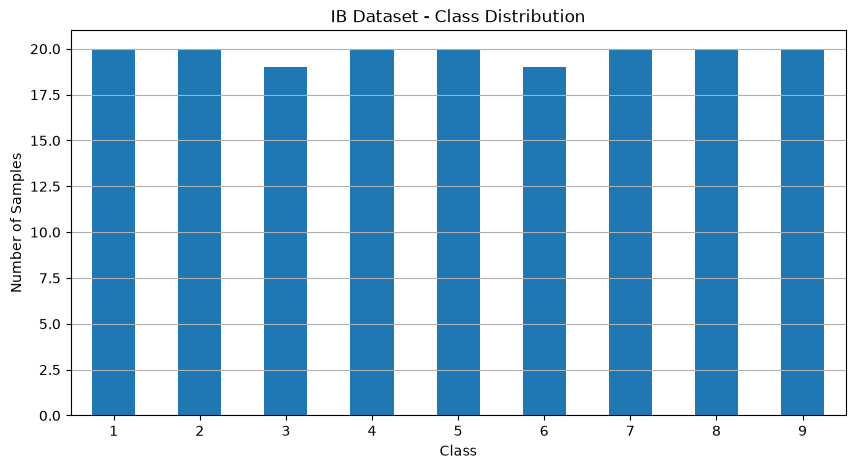

In [10]:
import matplotlib.pyplot as plt

print("=== IB CLASS DISTRIBUTION ===")

class_counts = ib_df["Label"].value_counts().sort_index()

print(class_counts)

print("\nTotal samples:", len(ib_df))
print("Number of classes:", ib_df["Label"].nunique())

plt.figure(figsize=(10, 5))

class_counts.plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("IB Dataset - Class Distribution")
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.show()

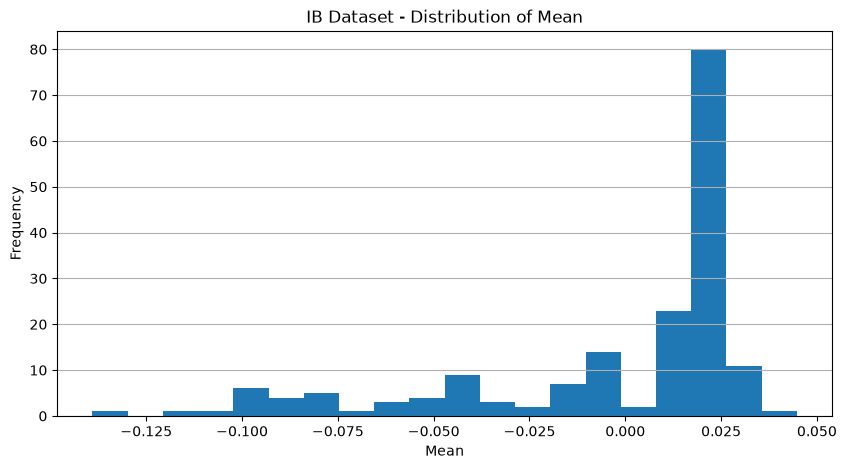

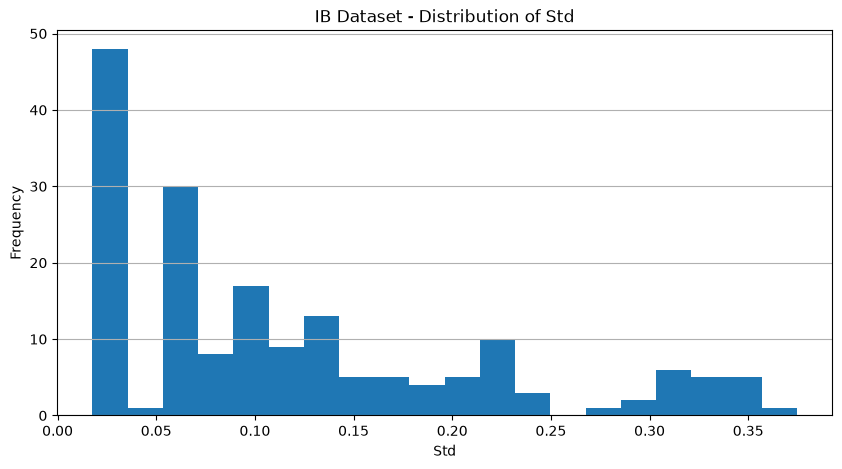

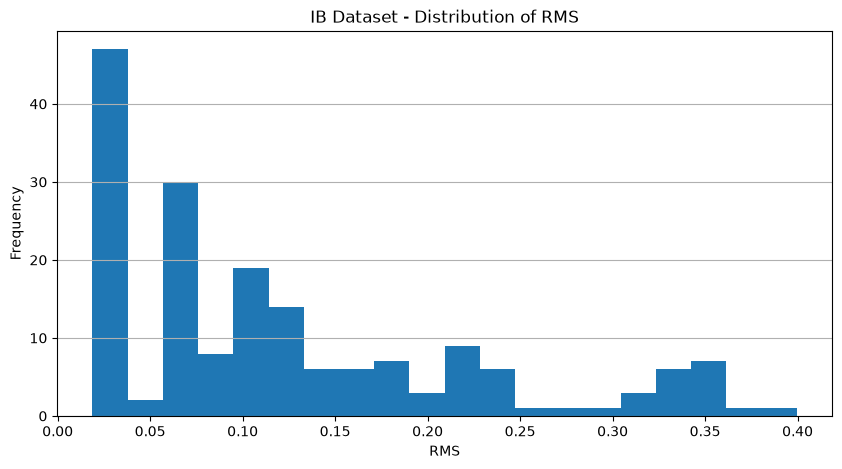

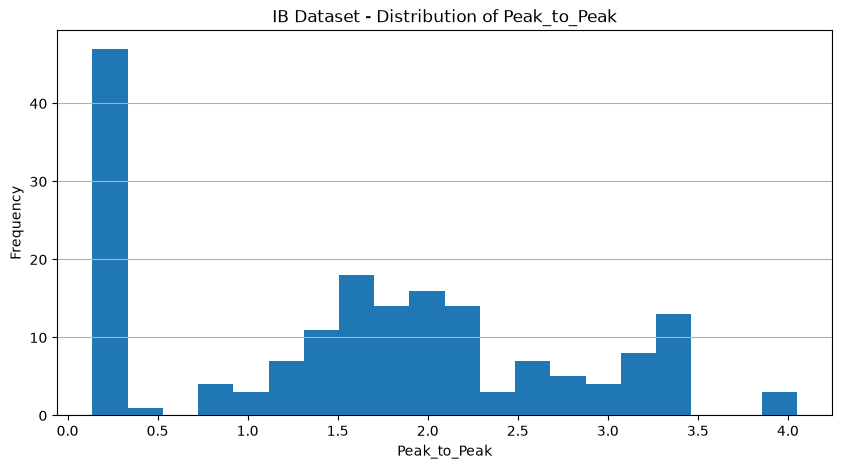

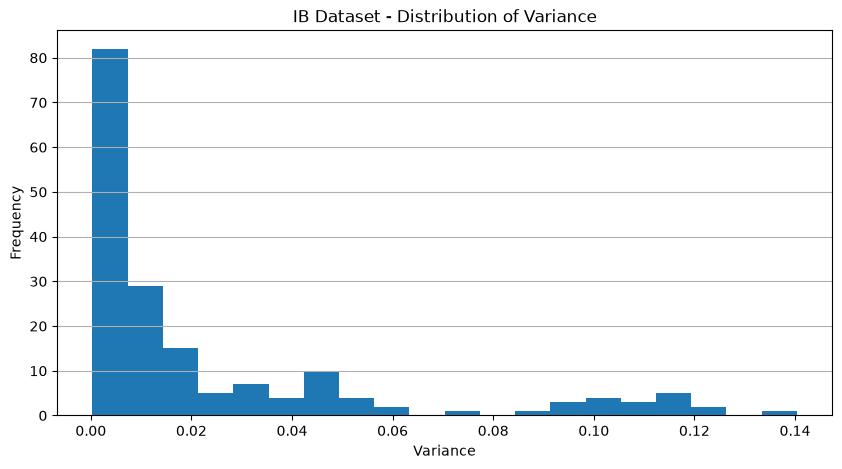

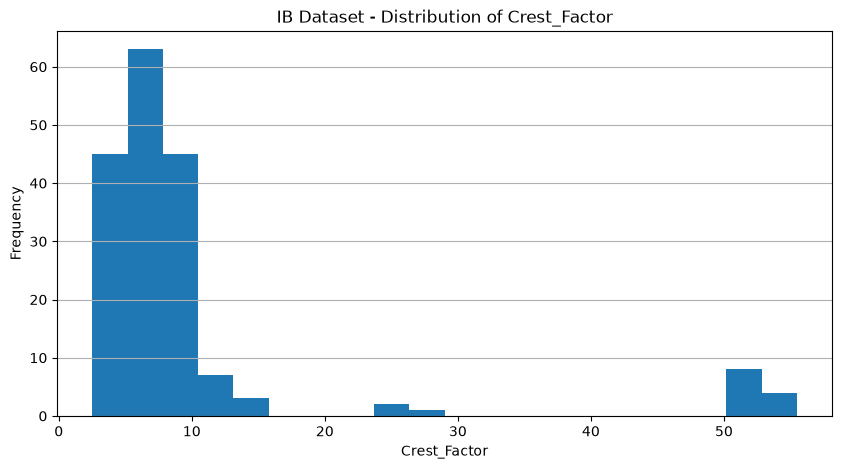

In [11]:
import matplotlib.pyplot as plt

features_to_plot = [
    "Mean",
    "Std",
    "RMS",
    "Peak_to_Peak",
    "Variance",
    "Crest_Factor"
]

for feature in features_to_plot:

    plt.figure(figsize=(10, 5))

    plt.hist(ib_df[feature], bins=20)

    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.title(f"IB Dataset - Distribution of {feature}")

    plt.grid(axis="y")
    plt.show()

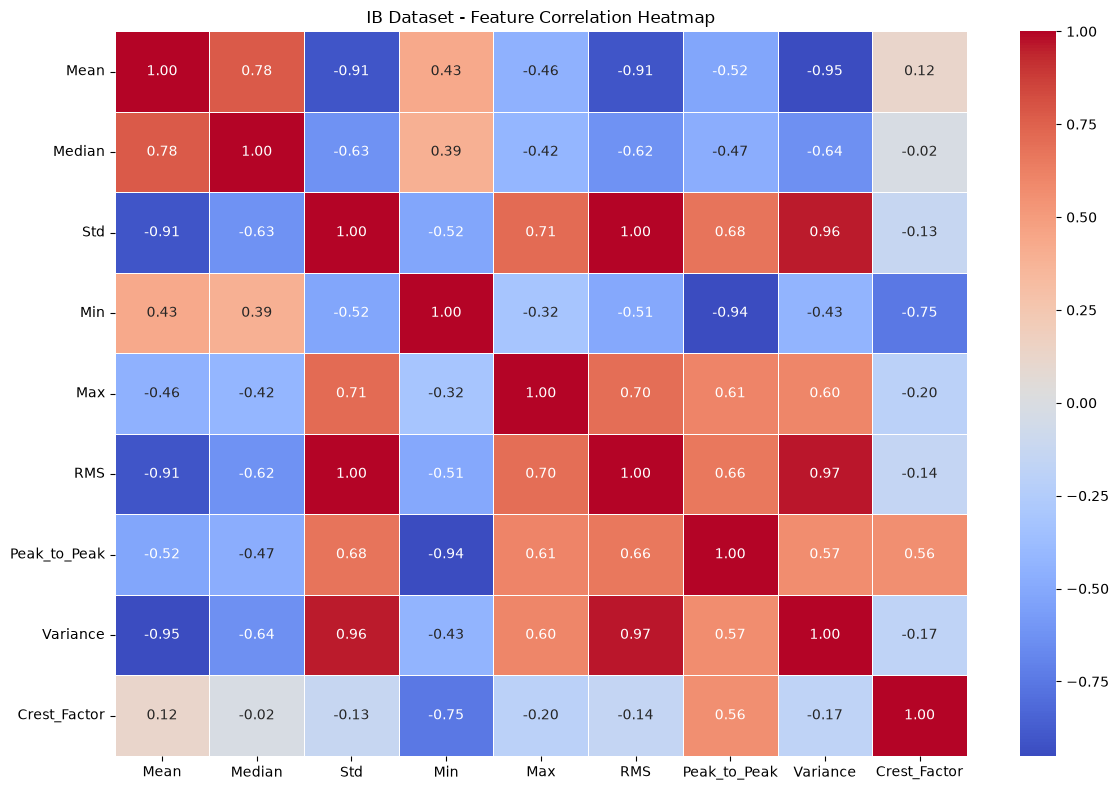

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical feature columns
correlation_data = ib_df[
    [
        "Mean",
        "Median",
        "Std",
        "Min",
        "Max",
        "RMS",
        "Peak_to_Peak",
        "Variance",
        "Crest_Factor"
    ]
]

# Calculate correlation
correlation_matrix = correlation_data.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("IB Dataset - Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [13]:
import os
import pandas as pd

# Output folder
processed_folder = r"C:\MachineHealthProject\processed"

# Create folder if it does not exist
os.makedirs(processed_folder, exist_ok=True)

# Output file
ib_output_path = os.path.join(
    processed_folder,
    "IB_processed.csv"
)

# Save dataset
ib_df.to_csv(ib_output_path, index=False)

print("IB processed dataset saved successfully:")
print(ib_output_path)

# Verify saved file
ib_check = pd.read_csv(ib_output_path)

print("\n=== SAVED DATASET CHECK ===")
print("Rows:", ib_check.shape[0])
print("Columns:", ib_check.shape[1])

print("\nColumns:")
print(list(ib_check.columns))

print("\nFirst 5 rows:")
display(ib_check.head())

IB processed dataset saved successfully:
C:\MachineHealthProject\processed\IB_processed.csv

=== SAVED DATASET CHECK ===
Rows: 178
Columns: 12

Columns:
['Sample', 'Label', 'Samples', 'Mean', 'Median', 'Std', 'Min', 'Max', 'RMS', 'Peak_to_Peak', 'Variance', 'Crest_Factor']

First 5 rows:


,Sample,Label,Samples,Mean,Median,Std,Min,Max,RMS,Peak_to_Peak,Variance,Crest_Factor
0,1,1,3571,0.009641,0.0098,0.017640,-0.0845,0.0711,0.020103,0.1556,0.000311,4.203444
1,2,1,3571,0.010269,0.0108,0.059201,-3.3340,0.1002,0.060085,3.4342,0.003505,55.488031
2,3,1,3571,0.008430,0.0088,0.018029,-0.0874,0.0750,0.019902,0.1624,0.000325,4.391489
3,4,1,3571,0.044781,0.0458,0.018601,-0.0495,0.1226,0.048490,0.1721,0.000346,2.528338
4,5,1,3571,0.012959,0.0137,0.018746,-0.0709,0.0720,0.022789,0.1429,0.000351,3.159440
